<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo Semanal Nº6
#### Federico Borello

### Consigna

<div align="center">

| Función de aproximación | Frecuencia de corte inferior | Frecuencia de corte superior | Frecuencia de stop (f₁) | Frecuencia de stop (f₂) | Ganancia máxima en banda de paso | Ripple máximo en banda de paso | Atenuación mínima fuera de banda |
|:------------------------:|:-----------------------------:|:-----------------------------:|:------------------------:|:------------------------:|:--------------------------------:|:------------------------------:|:-------------------------------:|
|     Máxima planicidad    |           1600 kHz            |           2500 kHz            |         1250 kHz         |         3200 kHz         |              10 dB               |            3 dB               |             20 dB              |

</div>

Se pide:

👉 01. Obtener la plantilla de diseño objetivo del filtro pasabanda y la plantilla de diseño prototipo del filtro pasabajo que satisfaga el requerimiento del filtro pasabanda: ¡ambas normalizadas!

👉 02. Obtener las funciones transferencia normalizadas de ambos filtros.


👉 03. Realice el estudio de la función transferencia normalizada del filtro pasabanda correspondiente a la respuesta en frecuencia (módulo y fase), en aquellos puntos que considere característicos, y al diagrama de polos y ceros.


👉 04. Sintetizar el filtro utilizando estructuras Ackerberg-Mossberg.


👉 05. Simular numéricamente en Python y circuitalmente en LTSpice la función transferencia pasabanda desnormalizada del filtro obtenido verificando las especificaciones de diseño. Seleccione convenientemente la norma de impedancia según los criterios vistos en clase.


**Bonus:**


+10 💎 Implemente el mismo filtro con una función de aproximación de módulo Chebyshev.


+10 💎 Simular numéricamente en Python y circuitalmente en LTSpice la función transferencia desnormalizada del filtro obtenido verificando las especificaciones de diseño. Seleccione convenientemente la norma de impedancia según los criterios vistos en clase.

In [1]:
from IPython.display import HTML

file = "./TS6_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import scipy.signal as sig
from scipy.signal import TransferFunction, freqresp
from pytc2.sistemas_lineales import (
    analyze_sys,
    pretty_print_lti,
    tf2sos_analog,
    pretty_print_SOS,
)
from pytc2.general import print_latex, print_subtitle

# Análisis Previo

Dado un sistema en cascada de tres secciones con funciones transferencia sin ganancia:

$$
t_1(s), \quad t_2(s), \quad t_3(s)
$$

Se definen los máximos de magnitud en frecuencia como:

$$
M_1 = \max_{\omega} |t_1(j\omega)|, \quad
M_2 = \max_{\omega} |t_1(j\omega) t_2(j\omega)|, \quad
M_3 = \max_{\omega} |t_1(j\omega) t_2(j\omega) t_3(j\omega)|
$$

El objetivo es asignar ganancias escalares $k_1, k_2, k_3$ a cada sección para que la función transferencia total

$$
T_B(s) = k_1 k_2 k_3 \cdot t_1(s) t_2(s) t_3(s)
$$

alcance una ganancia máxima deseada $G$, es decir,

$$
\max_{\omega} |T_B(j\omega)| = G
$$

Como el máximo módulo del producto sin ganancia es $M_3$, se define

$$
K = \frac{G}{M_3}
$$

y se cumple que

$$
k_1 k_2 k_3 = K
$$

Para distribuir las ganancias de forma que cada etapa opere en su máximo cuando la cascada total está en su máximo, se usan las siguientes relaciones (Schaumann, Cap. 5.3):

$$
k_1 = K \frac{M_3}{M_1}, \quad
k_2 = \frac{M_1}{M_2}, \quad
k_3 = \frac{M_2}{M_3}
$$

permitiendo asignar las ganancias óptimas para maximizar el rango dinámico y minimizar distorsiones en la cascada.

---

Este esquema permite calcular sistemáticamente las ganancias $k_i$ a partir de los máximos $M_i$ obtenidos de la respuesta en frecuencia de las funciones transferencia parciales.


## Caso de Estudio

Se utiliza la función transferencia obtenida a mano en el PDF adjunto.

In [3]:
Q = sp.symbols("Q", real=True, positive=True)
s = sp.symbols("s")

# Defino la transferencia T(s)
num = s**3 / Q**3
den1 = s**6 + 2 / Q * s**5 + (1 + 1 / Q**2 + (2 * Q**2 + 1) / Q**2) * s**4
den2 = (
    (2 / Q + (2 * Q**2 + 1) / Q**3) * s**3
    + (1 + 1 / Q**2 + (2 * Q**2 + 1) / Q**2) * s**2
    + 2 / Q * s
    + 1
)
den = den1 + den2
T = num / den

T

s**3/(Q**3*(s**6 + s**4*(1 + (2*Q**2 + 1)/Q**2 + Q**(-2)) + s**3*(2/Q + (2*Q**2 + 1)/Q**3) + s**2*(1 + (2*Q**2 + 1)/Q**2 + Q**(-2)) + 1 + 2*s**5/Q + 2*s/Q))

$$H(s) = 0.0914 \frac{1s^3}{1s^6 + 0.901s^5 + 3.41s^4 + 1.89s^3 + 3.41s^2 + 0.901s + 1}$$

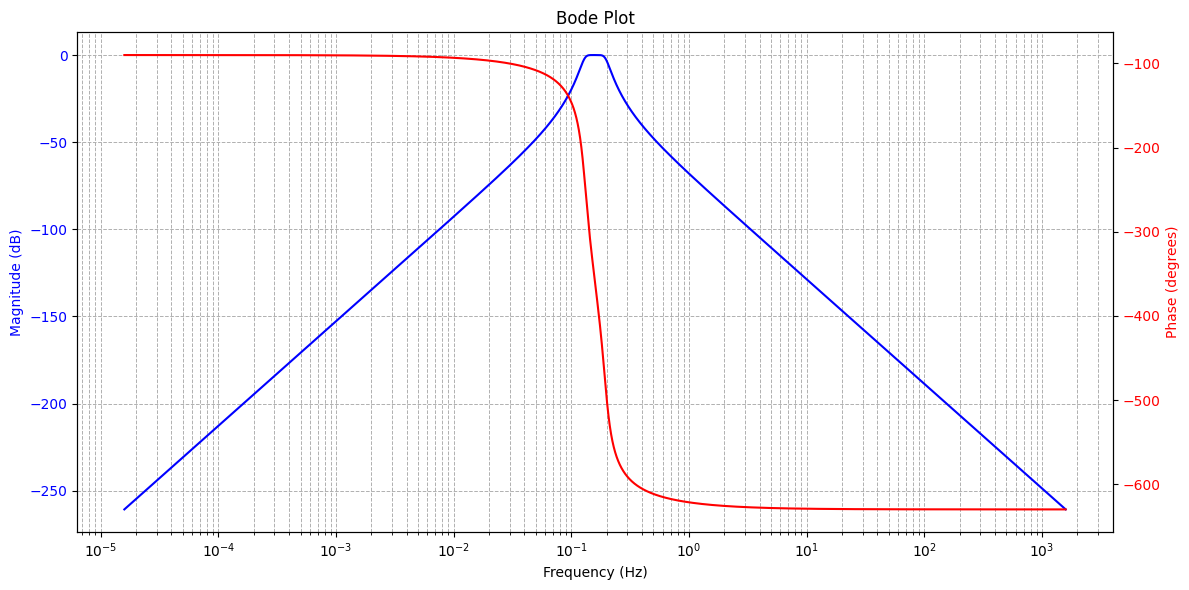

In [4]:
T = T.subs(Q, 2.22)
T = T.simplify()
_ = uplt.plot_tf(T, {}, 1 / (2 * np.pi))

Resulta más complejo sintetizar un circuito de orden 6, por ello, se lo dividió en tres secciones de segundo orden. 

$$
T(s) = T_1(s) \, \cdot \, T_2(s) \, \cdot \, T_3(s)
$$

Que a su vez:

$$
T_1(s) = \cfrac{k_1 \, s}{s^2+s\frac{1}{2.22}+1}
$$

$$
T_2(s) = \cfrac{k_2 \, s}{s^2+s \, 0.268+1.477}
$$

$$
T_3(s) = \cfrac{k_3 \, s}{s^2+s \, 0.182+0.677}
$$

Con este esquema, aplicamos los conceptos de la sección **Análisis Previo** de forma numérica. Además, incluímos una ganancia total a; sistema: 

$$
10 [dB] \quad \rightarrow \quad G = 3.16
$$

In [5]:
t1 = TransferFunction([1, 0], [1, 1 / 2.22, 1])
t2 = TransferFunction([1, 0], [1, 0.268, 1.4771])
t3 = TransferFunction([1, 0], [1, 0.1818, 0.67695])

w = np.logspace(0, 2, 100)

_, h1 = freqresp(t1, w)
_, h2 = freqresp(t2, w)
_, h3 = freqresp(t3, w)

modulo_product2 = np.abs(h1) * np.abs(h2)
modulo_product3 = modulo_product2 * np.abs(h3)

M1 = np.max(np.abs(h1))
M2 = np.max(modulo_product2)
M3 = np.max(modulo_product3)

G = 3.16
K = G / M3

# Según Schaumann
k1 = K * (M3 / M1)
k2 = M1 / M2
k3 = M2 / M3

markdown_text = f"""
<div align="center">

$M_1 = {M1:.4f}$

$M_2 = {M2:.4f}$

$M_3 = {M3:.4f}$

$G = {G:.4f}$

$K = \\frac{{G}}{{M_3}} = {K:.4f}$

$k_1 = K \\cdot \\frac{{M_3}}{{M_1}} = {k1:.4f}$

$k_2 = \\frac{{M_1}}{{M_2}} = {k2:.4f}$

$k_3 = \\frac{{M_2}}{{M_3}} = {k3:.4f}$

$k_1 \\cdot k_2 \\cdot k_3 = {k1*k2*k3:.4f} \\quad == \\quad K = {K:.4f}$

</div>

Con estos datos se podrían completar las secciones del filtro ya especificadas.
Se procede graficando rapidamente la respuesta en frecuencia de la transferencia.
"""
display(Markdown(markdown_text))


<div align="center">

$M_1 = 2.2200$

$M_2 = 6.3502$

$M_3 = 10.9465$

$G = 3.1600$

$K = \frac{G}{M_3} = 0.2887$

$k_1 = K \cdot \frac{M_3}{M_1} = 1.4234$

$k_2 = \frac{M_1}{M_2} = 0.3496$

$k_3 = \frac{M_2}{M_3} = 0.5801$

$k_1 \cdot k_2 \cdot k_3 = 0.2887 \quad == \quad K = 0.2887$

</div>

Con estos datos se podrían completar las secciones del filtro ya especificadas.
Se procede graficando rapidamente la respuesta en frecuencia de la transferencia.


$$H(s) = 0.289 \frac{1s^3}{1s^6 + 0.9s^5 + 3.41s^4 + 1.89s^3 + 3.41s^2 + 0.9s + 1}$$

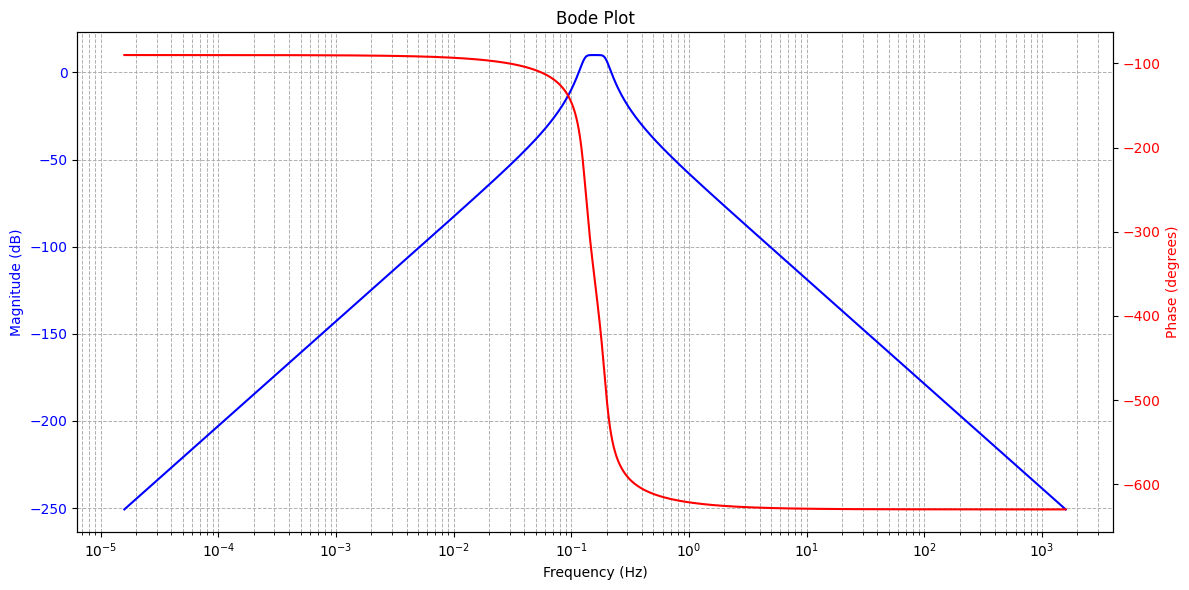


Ganancia en $\omega_0$ 9.992[dB] = 3.159[veces]


In [6]:
num12 = np.convolve(t1.num, t2.num)
den12 = np.convolve(t1.den, t2.den)
num123 = np.convolve(num12, t3.num)
den123 = np.convolve(den12, t3.den)
K = k1 * k2 * k3
t_total = TransferFunction(K * num123, den123)

s = sp.symbols("s")
num_poly = sum(K * coef * s**i for i, coef in enumerate(reversed(num123)))
den_poly = sum(coef * s**i for i, coef in enumerate(reversed(den123)))
tf_sym = num_poly / den_poly
(magnitude_db, frequencies, _) = uplt.plot_tf(tf_sym, {}, 1 / (2 * np.pi))
idx = np.argmin(np.abs(frequencies - 1 / (2 * np.pi)))
magnitude_at_w0 = magnitude_db[idx]

markdown_text = f"""
Ganancia en $\omega_0$ {magnitude_at_w0:.3f}[dB] = {10**(magnitude_at_w0/20):.3f}[veces]
"""

display(Markdown(markdown_text))

## Análisis con modulo pytc2

In [7]:
num_coeffs = sp.Poly(T.as_numer_denom()[0], s).all_coeffs()
den_coeffs = sp.Poly(T.as_numer_denom()[1], s).all_coeffs()
num_coeffs = [float(c) for c in num_coeffs]
den_coeffs = [float(c) for c in den_coeffs]

num = num_coeffs
den = den_coeffs

In [8]:
# https://pytc2.readthedocs.io/en/latest/notebooks/ejnb_secciones_SOS.html
k0db = 0
k0 = 10
k_corr = 10 ** ((k0 - k0db) / 20)
num = k_corr * np.array(num)

sos_pb = tf2sos_analog(num, den)
sos_pb[sos_pb < 1e-6] = 0.0
print_subtitle("Transferencia factorizada")
pretty_print_SOS(sos_pb)
print_subtitle("Transferencia factorizada y parametrizada")
pretty_print_SOS(sos_pb, mode="omegayq")

#### Transferencia factorizada

<IPython.core.display.Math object>

#### Transferencia factorizada y parametrizada

<IPython.core.display.Math object>

Verificamos que los valores del análisis anterior concuerdan con la factorización SOS.

## Síntesis

Se procede a sintetizar el circuito con 3 Ackerberg-Mossberg separados por buffers. Definiendo la capacitancia y luego los valores de los resistores como en las TSs previas.

## Gráfico de Modulo y Fase

### Simulación con LT Spice

Circuito:

<div align=center>


</div>

Módulo y Fase:

<div align=center>


</div>

<a href="./TS6.asc" download="TS6.asc">Descargar TS6.asc</a>